In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('results/metrics_data.xlsx',"EnergyTimeSeries")

/home/jaki/Git/SnapPattern/Python/env/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


<Axes: xlabel='StepIndex', ylabel='Energy (Joules)'>

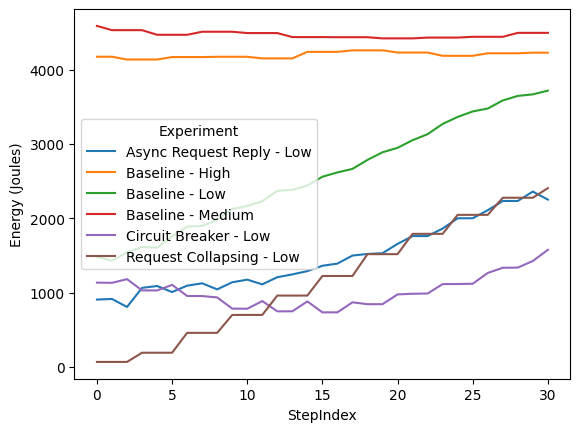

In [ ]:
df2 = df.groupby(["Pattern","Workload","StepIndex"])["Energy (Joules)"].mean().reset_index()
df2["Experiment"] = df2["Pattern"] + " - " + df2["Workload"]
sns.lineplot(
    data=df2.groupby(["Experiment","StepIndex"])["Energy (Joules)"].mean().reset_index(),
    x="StepIndex",             # or use "StepIndex" for simpler x-axis
    y="Energy (Joules)",
    hue="Experiment",               # one line per RunID
    estimator=None             # plot raw values instead of mean
)

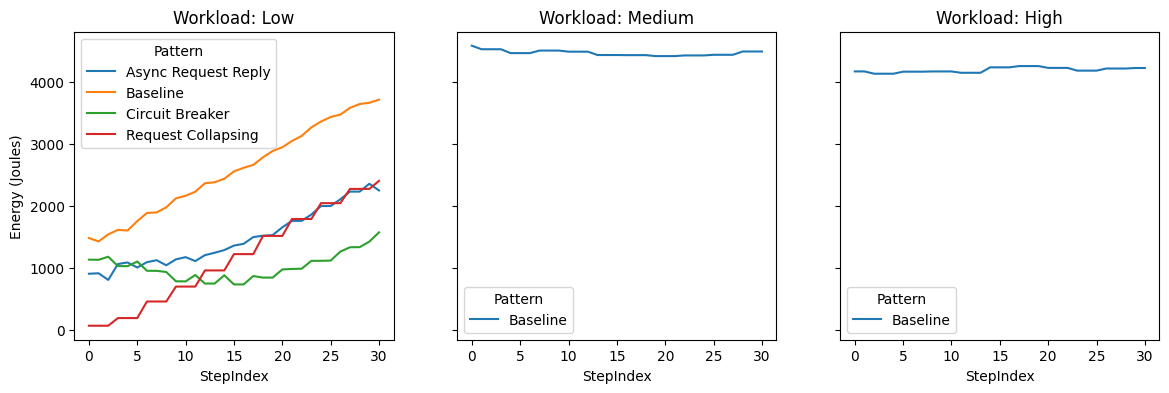

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
ax = {"Low": 0,
    "Medium": 1,
    "High": 2}
for workload, group in df.groupby("Workload"):
    sns.lineplot(
        data=group.groupby(["Pattern", "StepIndex"])["Energy (Joules)"].mean().reset_index().sort_values("Pattern"),
        x="StepIndex",
        y="Energy (Joules)",
        hue="Pattern",
        ax=axes[ax[workload]],
        estimator=None,
        legend=True
    )
    axes[ax[workload]].set_title(f"Workload: {workload}")


#handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.05))


In [57]:
fig.savefig("results/plots/energy-pipeline_plot.eps", dpi=300, bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
